# Heat Flow versus Porous-Medium Flow

This notebook generates `fig:gradflow-heat-versus-porous-medium`.  The entropy flow gives the heat equation
$$
    \partial_t \rho = \Delta \rho,
$$
while the power entropy $g(\rho)=\rho^m/(m-1)$ gives the porous-medium equation
$$
    \partial_t \rho = \Delta(\rho^m).
$$
We use $m=2$ and $m=6$ and plot only the evolving densities, leaving labels and parameter values to LaTeX.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks-figures"))

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    ORANGE,
    GRAY,
    LIGHT_GRAY,
    DIRAC_MARKER_SIZE,
    box_axes,
    draw_point_clouds,
    draw_transport_segments,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "gradflow-heat-versus-porous-medium"
out = figure_dir(NAME)

The computation is analytic and lightweight.  The heat panel convolves a compact initial density with Gaussian kernels; the porous-medium panel uses Barenblatt-like compact profiles with expanding support.

In [2]:
x = np.linspace(-3.4, 3.4, 1000)
times = np.array([0.0, 0.035, 0.12, 0.32])
rho0 = np.maximum(1 - (x / 0.72)**2, 0.0) ** 1.7
rho0 /= np.trapezoid(rho0, x)

def heat_from_initial(t):
    if t == 0:
        return rho0.copy()
    sigma = np.sqrt(2 * t)
    dx = x[1] - x[0]
    diff = x[:, None] - x[None, :]
    K = np.exp(-0.5 * diff**2 / sigma**2) / (np.sqrt(2*np.pi) * sigma)
    rho = K @ rho0 * dx
    return rho / np.trapezoid(rho, x)

def barenblatt_like(t, m=2.0, spread=1.55):
    R = 0.72 + spread * np.sqrt(t + 0.012) - spread * np.sqrt(0.012)
    rho = np.maximum(1 - (x / R)**2, 0.0) ** (1 / (m - 1))
    return rho / np.trapezoid(rho, x)

heat = [heat_from_initial(t) for t in times]
pm2 = [rho0] + [barenblatt_like(t, m=2.0, spread=1.55) for t in times[1:]]
pm6 = [rho0] + [barenblatt_like(t, m=6.0, spread=1.05) for t in times[1:]]

In [3]:
def draw_family(ax, curves):
    for k, rho in enumerate(curves):
        color = interp_color(k/(len(curves)-1))
        ax.plot(x, rho, color=color, lw=1.15)
        ax.fill_between(x, 0, rho, color=color, alpha=0.055)
    ax.set_xlim(-2.8, 2.8)
    ax.set_ylim(0, max(curves[0]) * 1.10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=7, pad=1.5)
    box_axes(ax)

def plot_family(curves, filename):
    fig, ax = plt.subplots(figsize=(3.05, 1.62))
    draw_family(ax, curves)
    save_pdf(fig, out / filename, pad_inches=0.045)
    plt.close(fig)

plot_family(heat, "heat.pdf")
plot_family(pm2, "porous-medium.pdf")
plot_family(pm6, "porous-medium-m6.pdf")

thumb_dir = ROOT / "notebooks-figures" / "thumbnails"
thumb_dir.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(7.2, 1.9))
for ax, curves in zip(axes, [heat, pm2, pm6]):
    draw_family(ax, curves)
fig.subplots_adjust(left=0.035, right=0.99, bottom=0.18, top=0.96, wspace=0.20)
fig.savefig(thumb_dir / "gradflow-heat-versus-porous-medium.png", dpi=180)
plt.close(fig)

## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


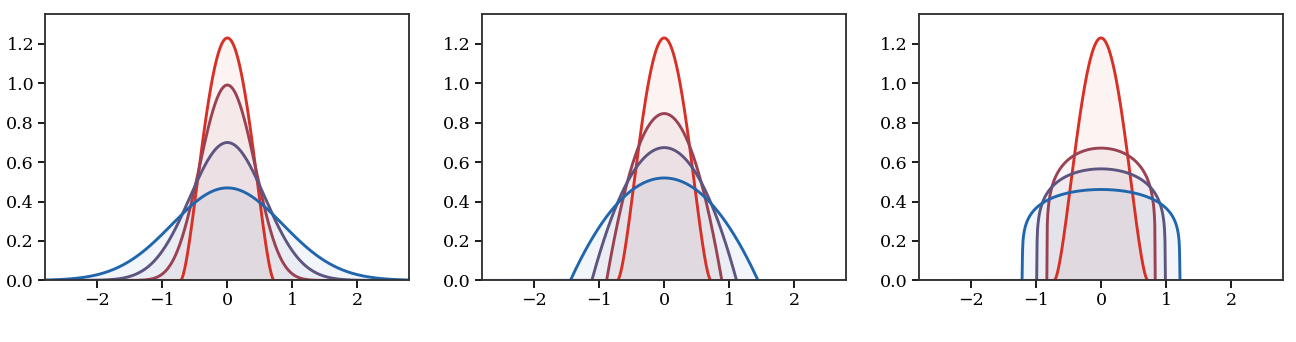

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/gradflow-heat-versus-porous-medium.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/gradflow-heat-versus-porous-medium.png")
display(Image(filename=str(_thumb)))
